In [ ]:
import os
import math
import csv
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from time import sleep
from collections import deque, defaultdict
from itertools import count
from typing import Any, Dict, Counter, List
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch_optimizer as optim_extra

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv, DrlPolicy
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapper import EnvWrapper

import importlib
import config

importlib.reload(config)

In [ ]:
cfg = config.Config()

filename: str = f"drl_ddqn_lrdecay{cfg.learning_rate_decay}_c{cfg.cache_size}_ar{cfg.arrival_rate}_z{cfg.zipf_alpha}.csv"
filename: str = f"drl_ddqn_fixedlr{cfg.learning_rate}_c{cfg.cache_size}_ar{cfg.arrival_rate}_z{cfg.zipf_alpha}.csv"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DQN(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        hidden = 64
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)  # linear

class ReplayBuffer:
    def __init__(self, capacity: int = 2000):
        self.memory = deque(maxlen=capacity)
    
    def push(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))
    
    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

class DQNAgent:
    def __init__(self, cfg: Any):
        self.step = 0
        
        self.state_dim = cfg.state_dim
        self.action_dim = cfg.action_dim
        
        self.epsilon = cfg.epsilon_start
        self.epsilon_min = cfg.epsilon_min
        self.epsilon_decay = cfg.epsilon_decay
        self.gamma = cfg.gamma
        self.tau = cfg.tau
        self.batch_size = cfg.batch_size
        
        self.buffer = ReplayBuffer(cfg.buffer_capacity)
        
        self.policy_net = DQN(self.state_dim, self.action_dim).to(device)
        self.target_net = DQN(self.state_dim, self.action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.learning_rate)
         
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(
            self.optimizer, 
            gamma=cfg.learning_rate_decay
        )
        
        self.loss_fn = nn.MSELoss()
        self.nb_interval = cfg.nb_interval  # train every 5 requests

    def select_action(self, state):
        if random.random() < self.epsilon:
            action_idx = random.randint(0, self.action_dim - 1)
            return action_idx, None
        
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.policy_net(state)
        
        action_idx = q_values.argmax().item()
        return action_idx, q_values
        
    def remember(self, s, a, r, ns, done):
        self.buffer.push(s, a, r, ns, done)

    def train_step(self):
        self.step += 1
        if self.step % self.nb_interval == 0 and \
           len(self.buffer) >= self.batch_size:
            self.learn()

    def learn(self):
        batch = self.buffer.sample(self.batch_size)
        s, a, r, ns, d = zip(*batch)
        s = torch.tensor(np.stack(s), dtype=torch.float32).to(device)
        ns = torch.tensor(np.stack(ns), dtype=torch.float32).to(device)
        a = torch.tensor(a, dtype=torch.int64).to(device)
        r = torch.tensor(r, dtype=torch.float32).to(device)
        d = torch.tensor(d, dtype=torch.float32).to(device)

        with torch.no_grad():
            next_q_main = self.policy_net(ns)
            best_actions = next_q_main.argmax(dim=1)

            next_q_target = self.target_net(ns)
            double_q = next_q_target.gather(1, best_actions.unsqueeze(1)).squeeze(1)

            q_target = r + self.gamma * double_q * (1.0 - d)

        q_expected = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        loss = self.loss_fn(q_expected, q_target)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        # self.scheduler.step()
        
        self.update_target()

    def soft_update_target(self):
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_( 
                target_param.data * (1.0 - self.tau) + policy_param.data * self.tau
            )

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset_step(self):
        self.step = 0

In [15]:
def save_training_results(
    path_,
    filename,
    ep, 
    total_reward, 
    cache_hits, 
    cache_misses, 
    soft_hits,
    agent
):
    with open(os.path.join(path_, filename), 'a', newline='') as f:
        fieldnames = [
            'episode', 
            'total_reward', 
            'cache_hits', 
            'cache_misses', 
            'soft_hits',
            'epsilon',
            'lr'
        ]
        writer_results = csv.DictWriter(f, fieldnames=fieldnames)

        if ep == 0:
            writer_results.writeheader()
        
        writer_results.writerow({
            'episode': ep,
            'total_reward': round(float(total_reward), 2),
            'cache_hits': cache_hits,
            'cache_misses': cache_misses,
            'soft_hits': soft_hits,
            'lr': f"{agent.scheduler.get_last_lr()[0]:.10f}" if agent else None,
            'epsilon': round(float(agent.epsilon), 4) if agent else None
        })

def update_metrics(info: dict, reward: float) -> tuple[float, int, int, float]:
    enh_hits = info.get("enh_layer_cache_hits", 0)
    base_hits = info.get("base_layer_cache_hits", 0)
    enh_misses = info.get("enh_layer_cache_misses", 0)
    base_misses = info.get("base_layer_cache_misses", 0)
    soft_hits = info.get("soft_hits", 0.0)

    return reward, (enh_hits + base_hits), (enh_misses + base_misses), soft_hits

In [ ]:
class FeatureAdapter:
    def __init__(self, env: CacheEngineEnv, cfg: Any):
        self.env = env
        self.cfg = cfg

        self.video_hist_short = deque(maxlen=cfg.h_short)
        self.video_hist_long = deque(maxlen=cfg.h_long)
        self.tile_hist_short = deque(maxlen=cfg.h_short)
        self.tile_hist_long = deque(maxlen=cfg.h_long)
        self.tiles_hist_short = deque(maxlen=cfg.h_short)
        self.tiles_hist_long = deque(maxlen=cfg.h_long)

        self.video_freq_short = defaultdict(int)
        self.video_freq_long = defaultdict(int)
        self.tile_freq_short = defaultdict(int)
        self.tile_freq_long = defaultdict(int)
        self.tiles_freq_short = defaultdict(int)
        self.tiles_freq_long = defaultdict(int)

    def reset_history(self):
        queues = (
            self.video_hist_short,
            self.video_hist_long,
            self.tiles_hist_short,
            self.tiles_hist_long,
            self.tile_hist_short,
            self.tile_hist_long,
        )
        freqs = (
            self.video_freq_short,
            self.video_freq_long,
            self.tiles_freq_short,
            self.tiles_freq_long,
            self.tile_freq_short,
            self.tile_freq_long,
        )
        
        for q in queues:
            q.clear()
        for f in freqs:
            f.clear()

    def update_history(self, vid: int, tiles: list[int]):       
        self._update_window(self.video_hist_short, self.video_freq_short, vid)
        self._update_window(self.video_hist_long, self.video_freq_long, vid)

        tiles = tuple(tiles) if tiles is not None else None

        if tiles is None:
            return

        self._update_window(self.tiles_hist_short, self.tiles_freq_short, tiles)
        self._update_window(self.tiles_hist_long, self.tiles_freq_long, tiles)

        for tile in tiles:
            self._update_window(self.tile_hist_short, self.tile_freq_short, (vid, tile))
            self._update_window(self.tile_hist_long, self.tile_freq_long, (vid, tile))

    def _update_window(self, hist_queue: deque, freq_dict: Dict, item):
        if len(hist_queue) == hist_queue.maxlen:
            old_item = hist_queue.popleft()
            freq_dict[old_item] -= 1
            if freq_dict[old_item] == 0:
                del freq_dict[old_item]
        hist_queue.append(item)
        freq_dict[item] += 1


In [17]:
class NetworkAdapter:
    def __init__(self, env: EnvWrapper, feature_adapter: FeatureAdapter, cfg: Config):
        self.env = env
        self.cfg = cfg
        self.features = feature_adapter

        self.C = self.cfg.cache_size  # paper's cache capacity (videos)
        self.k = self.cfg.viewport    # paper's tiles per video (enhancement)

        print(f"NetworkAdapter initialized with capacity: {self.C} videos, {self.k} tiles per video")

    def build_observation(self, vid: int) -> np.ndarray:
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        x_s = np.zeros(self.C, dtype=np.float32)
        x_l = np.zeros(self.C, dtype=np.float32)

        y_s = np.zeros(self.C * self.k, dtype=np.float32)
        y_l = np.zeros(self.C * self.k, dtype=np.float32)

        for vid_i, v in enumerate(video_cache_index):
            if v == -1:
                continue
            x_s[vid_i] = self.features.video_freq_short.get(v, 0)
            x_l[vid_i] = self.features.video_freq_long.get(v, 0)

            tiles = tile_cache_index[vid_i]

            for til_i, t in enumerate(tiles):
                if t == -1:
                    continue
                y_s[vid_i * self.k + til_i] = self.features.tile_freq_short.get((v, t), 0)
                y_l[vid_i * self.k + til_i] = self.features.tile_freq_long.get((v, t), 0)

        z_s = np.array(
            [self.features.video_freq_short.get(vid, 0)], dtype=np.float32
        )
        z_l = np.array(
            [self.features.video_freq_long.get(vid, 0)], dtype=np.float32
        )

        return np.concatenate([x_s, x_l, y_s, y_l, z_s, z_l], axis=0)

    def build_observation_ordered(self, vid: int) -> np.ndarray:
        # Get current cached videos
        video_cache_index = self.env.mec_cache.policy.video_idx
        tile_cache_index = self.env.mec_cache.policy.tile_idx

        # --- FIX: Create a list of (video_id, slot_index) ---
        cached_items = []
        for slot_i, v_id in enumerate(video_cache_index):
            if v_id != -1:
                # We use long-term frequency for sorting to keep inputs stable
                freq = self.features.video_freq_long.get(v_id, 0)
                cached_items.append((freq, v_id, slot_i))
            else:
                # Empty slots go to the end
                cached_items.append((-1, -1, slot_i))
        
        # Sort descending by frequency (Strongest items first)
        cached_items.sort(key=lambda x: x[0], reverse=True)
        # ----------------------------------------------------

        x_s = np.zeros(self.C, dtype=np.float32)
        x_l = np.zeros(self.C, dtype=np.float32)
        y_s = np.zeros(self.C * self.k, dtype=np.float32)
        y_l = np.zeros(self.C * self.k, dtype=np.float32)

        # Iterate through the SORTED items to build the state
        for i, (freq, v, original_slot) in enumerate(cached_items):
            if v == -1: continue # Skip empty placeholders
            
            # Fill video features
            x_s[i] = np.log1p(self.features.video_freq_short.get(v, 0))
            x_l[i] = np.log1p(self.features.video_freq_long.get(v, 0))

            # Fill tile features using the original slot to look up specific tiles
            tiles = tile_cache_index[original_slot]
            for til_i, t in enumerate(tiles):
                if t == -1: continue
                y_s[i * self.k + til_i] = np.log1p(self.features.tile_freq_short.get((v, t), 0))
                y_l[i * self.k + til_i] = np.log1p(self.features.tile_freq_long.get((v, t), 0))

        # Current Request Features (remain the same)
        z_s = np.array([np.log1p(self.features.video_freq_short.get(vid, 0))], dtype=np.float32)
        z_l = np.array([np.log1p(self.features.video_freq_long.get(vid, 0))], dtype=np.float32)

        return np.concatenate([x_s, x_l, y_s, y_l, z_s, z_l], axis=0)

    def rank_viewport_tiles(
        self,
        vid: int,
        viewport: list[int],
        features: FeatureAdapter,
        alpha: float = 0.7,
        eps: float = 1e-6,
    ) -> list[int]:

        scores = {}

        for t in viewport:
            short_f = features.tile_freq_short.get((vid, t), 0)
            long_f = features.tile_freq_long.get((vid, t), 0)
        
            score = (alpha * short_f) + ((1.0 - alpha) * long_f) + eps
            scores[t] = score

        ranked = sorted(scores.keys(), key=lambda t: (-scores[t], t))
                
        return ranked
    
    def reset(self):
        
        obs, info = self.env.reset()
        self.features.reset_history()

        video_cache_index = [-1] * self.C
        tile_cache_index = [[-1] * self.k for _ in range(self.C)]

        cached_videos = random.sample(range(self.cfg.n_videos), k=self.C)
        video_cache_index = cached_videos

        # for each cached video, sample distinct tiles
        for i, _vid in enumerate(cached_videos):
            tiles = random.sample(range(self.cfg.n_tiles), k=self.k)
            tile_cache_index[i] = tiles

        self.env.mec_cache.policy.video_idx = video_cache_index
        self.env.mec_cache.policy.tile_idx = tile_cache_index
        
        self.env.mec_cache.cache_bitmap[:, :, :, :] = 0

        gop_id = 0  # default GOP for enhancement tiles
        for i, vid in enumerate(video_cache_index):
            if vid == -1:
                continue
            tiles = tile_cache_index[i][:self.k]
            
            # base layer cached for all GOPs
            self.env.mec_cache.cache_bitmap[vid, 0, :, :] = 1

            # enhancement tiles cached for GOP 0
            self.env.mec_cache.cache_bitmap[vid, 1, tiles, :] = 1
    
        # --- update feature history with cached contents ---
        for i, vid in enumerate(video_cache_index):
            if vid == -1:
                continue
            tiles = tile_cache_index[i]
            self.features.update_history(vid, tiles)
        # --- end feature update ---

        return obs, info
    
    def env_is_done(self) -> bool:
        return self.env.users_env.all_users_done()

In [ ]:
if __name__ == "__main__":
    print("--- Starting DRL Caching System ---")

    # 2. Initialize Environment
    du_caches = []

    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        policy=DrlPolicy(
            capacity=int(cfg.cache_capacity), 
            cfg=cfg
        )
    )

    # Initialize User Environment
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        m=cfg.m,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha
    )

    P = cfg.n_nodes; max_U = cfg.n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,  # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 20e6, dtype=float),    # 160 Mbps -> 20e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,  # 1 ms
        mec_fixed_delay=0.005, # 5 ms
        cloud_fixed_delay=0.1  # 100 ms
    )

    def prefetch(cache, action):
        return cache.drl_prefetching(action)
    
    env = EnvWrapper(
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=cfg.theta,
        lam=cfg.lam,
        prefetch_fn=prefetch
    )

    # 3. Initialize Agent
    agent = DQNAgent(cfg)

    feature_adapter = FeatureAdapter(env, cfg)
    net_adapter = NetworkAdapter(env, feature_adapter, cfg)

    for episode in range(cfg.n_episodes):

        obs, info = net_adapter.reset()
        agent.reset_step()

        cache_hits = 0
        cache_misses = 0
        soft_hits = 0.0
        total_reward = 0.0
        avg_psnr = []
        
        for step in count():

            req = info["user_request"]
            
            u = req["u"]
            v = req["video"]
            g = req["gop"]
            tiles = req["tiles"]
            viewport = req["viewport"]
            base_req_init = req["base_req_init"]

            has_base_layer = any(
                t.get("events", {}).get("alpha_M_u") == 1 for t in tiles
            )
            action_taken = False

            if not has_base_layer:
                cur_state = net_adapter.build_observation_ordered(v)
                action_idx, _ = agent.select_action(cur_state)

                should_cache = (action_idx == 1)
                if should_cache:
                    video_idx_list = env.mec_cache.policy.video_idx
                    freqs = [
                        net_adapter.features.video_freq_long.get(vid, 0) if vid != -1 else -1 for vid in video_idx_list
                    ]
                    victim_slot = np.argmin(freqs) 
                    a_idx = victim_slot + 1 
                else:
                    a_idx = 0

                action = {
                    'video': v,
                    'gop': 0,
                    'tiles': viewport,
                    'base_req_init': should_cache, 
                    'action_idx': a_idx
                }

                action_taken = True
            elif has_base_layer:
                
                bitmap = env.mec_cache.get_cache_bitmap()
            
                cached_tiles =  np.argwhere(bitmap[v, 1, :, 0] == 1).flatten().tolist()
                
                viewport_list = list(viewport)
                ranked_tiles = net_adapter.rank_viewport_tiles(
                    v, viewport_list + cached_tiles, net_adapter.features, alpha=0.7
                )

                action = {
                    'video': v,
                    'gop': 0,
                    'tiles': ranked_tiles[:cfg.viewport],
                    'base_req_init': False
                }
            # --- STEP ENV ---
            obs, reward, done, info = env.step(action)

            # --- UPDATE USER HISTORY & VIDEO POPULARITY ---
            net_adapter.features.update_history(v, viewport)
            
            if action_taken:
                next_state = net_adapter.build_observation_ordered(v)

                agent.remember(
                    cur_state, 
                    action_idx, 
                    reward, 
                    next_state, 
                    float(done)
                )
            
            agent.train_step()

            total_reward_delta, hits_delta, misses_delta, soft_hits_delta = update_metrics(info, reward)
            total_reward += total_reward_delta
            cache_hits += hits_delta
            cache_misses += misses_delta
            soft_hits += soft_hits_delta

            if net_adapter.env_is_done():
                break

            # if req:
            #     print(f"Step {step}, Request State: User {req['u']}, Video {req['video']}, GOP {req['gop']}")
            # else:
            #     print(f"Step {step}, No active user requests.")
            # print("----------------------------------------------------------------")

        agent.update_epsilon()

        save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=episode,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            soft_hits=soft_hits,
            agent=agent
        )

--- Starting DRL Caching System ---
NetworkAdapter initialized with capacity: 50 videos, 4 tiles per video


Loading data from: c:\Users\es25591\Workspace\CacheVideoPredict360\Results/drl_ddqn_fixedlr0.001_c50_ar10.0_z1.0.csv


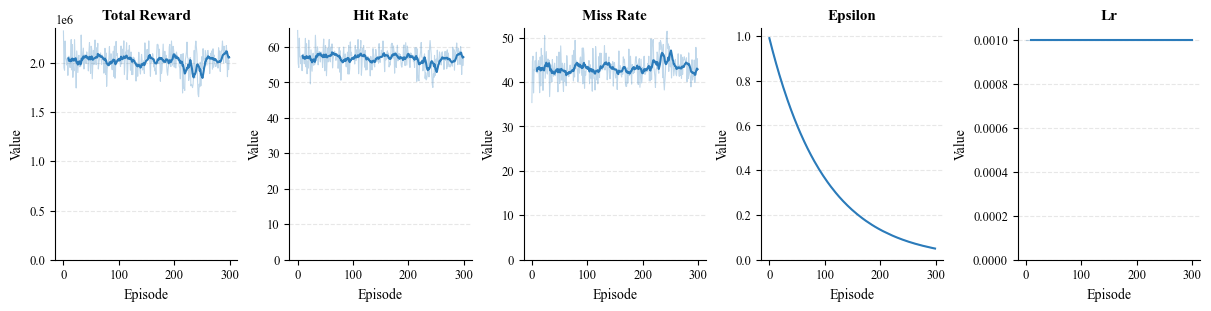

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 10  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value")
    ax.set_ylim(bottom=0)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)

['fixed lr: 0.001', 'lr decay: 0.9999']


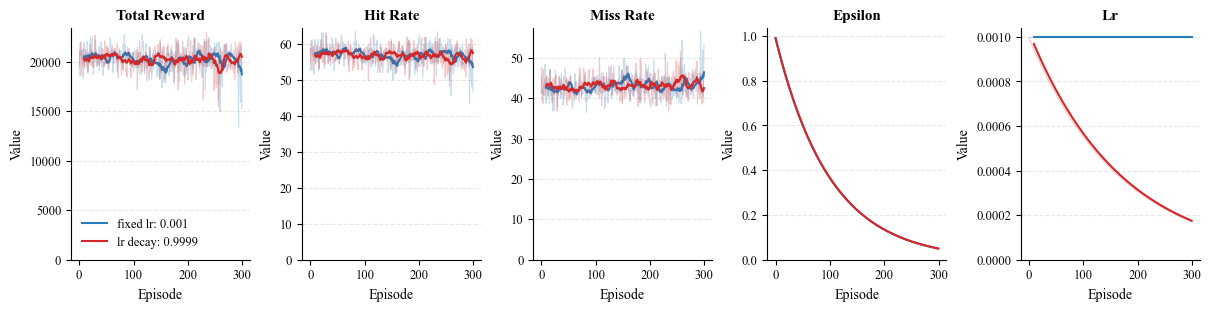

In [20]:
if __name__ == "__main__":
    cfg = Config()

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True
    })

    COLORS = ["#2b7bba", "#d62728", "#2ca02c"]

    folder = r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\interval_100_3"
    files = [
        "drl_pan_fixedlr0.001_c50_ar10.0_z1.0.csv",
        "drl_pan_lrdecay0.9999_c50_ar10.0_z1.0.csv",
        # "drl_pan_lrdecay0.99999_c50_ar10.0_z0.8.csv",
    ]

    paths = [os.path.join(folder, f) for f in files]
    def _short_label(fname: str) -> str:
        stem = os.path.splitext(fname)[0]
        if "lrdecay" in stem:
            val = stem.split("lrdecay", 1)[1].split("_", 1)[0]
            return f"lr decay: {val}"
        if "fixedlr" in stem:
            val = stem.split("fixedlr", 1)[1].split("_", 1)[0]
            return f"fixed lr: {val}"
        return stem

    labels = [_short_label(f) for f in files]

    print(labels)
    metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
    window_size = 10

    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

    for color, path, label in zip(COLORS, paths, labels):
        df = pd.read_csv(path)
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        df["hit_rate"] = (df["cache_hits"] / total) * 100
        df["miss_rate"] = (df["cache_misses"] / total) * 100

        for ax, col in zip(axes, metrics):
            ax.plot(df["episode"], df[col], color=color, alpha=0.25, linewidth=0.8)

            if col != "epsilon":
                smoothed = df[col].rolling(window=window_size).mean()
                ax.plot(df["episode"], smoothed, color=color, linewidth=1.5, label=label)
            else:
                ax.plot(df["episode"], df[col], color=color, linewidth=1.5, label=label)

    for ax, col in zip(axes, metrics):
        ax.set_title(col.replace("_", " ").title(), fontweight="bold")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Value")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.set_ylim(bottom=0)

    axes[0].legend(frameon=False, loc="best")
    plt.show()

    fig.savefig("interval_04_comparison.png", dpi=300)

C:\Users\es25591\AppData\Local\Temp\ipykernel_17000\1345644425.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


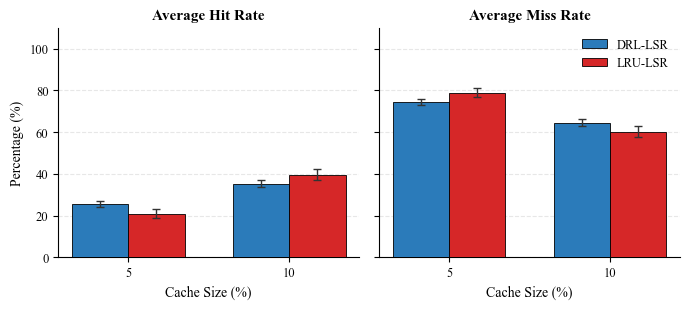

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

COLORS = ["#2b7bba", "#d62728"]

# ----------------------------------------------------------------
# 2. Data Preparation with Variance
# ----------------------------------------------------------------
def get_metrics_with_error(path):
    """Returns mean and standard deviation for hit and miss rates."""
    try:
        df = pd.read_csv(path)
        total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
        
        hit_series = (df["cache_hits"] / total * 100)
        miss_series = (df["cache_misses"] / total * 100)
        
        # Calculate Mean and Standard Deviation
        return (hit_series.mean(), hit_series.std()), (miss_series.mean(), miss_series.std())
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return (0, 0), (0, 0)

drl_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\drl_pan_opt_c50_ar10.0_z0.5.csv",
}

lsr_files = {
    "5": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c25_ar10.0_z0.5.csv",
    "10": r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results\lru_c50_ar10.0_z0.5.csv",
}

caps = list(drl_files.keys())
# Structure: { Metric: { Algo: [means], Algo_err: [stds] } }
stats = {
    "Hit Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []},
    "Miss Rate": {"DRL-LSR": [], "DRL-LSR_err": [], "LRU-LSR": [], "LRU-LSR_err": []}
}

for c in caps:
    (d_h, d_h_err), (d_m, d_m_err) = get_metrics_with_error(drl_files[c])
    (l_h, l_h_err), (l_m, l_m_err) = get_metrics_with_error(lsr_files[c])
    
    stats["Hit Rate"]["DRL-LSR"].append(d_h)
    stats["Hit Rate"]["DRL-LSR_err"].append(d_h_err)
    stats["Hit Rate"]["LRU-LSR"].append(l_h)
    stats["Hit Rate"]["LRU-LSR_err"].append(l_h_err)
    
    stats["Miss Rate"]["DRL-LSR"].append(d_m)
    stats["Miss Rate"]["DRL-LSR_err"].append(d_m_err)
    stats["Miss Rate"]["LRU-LSR"].append(l_m)
    stats["Miss Rate"]["LRU-LSR_err"].append(l_m_err)

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)
x = np.arange(len(caps))
width = 0.35 

# Error bar styling
error_kw = dict(lw=1, capsize=3, capthick=1, ecolor='#333333')

metrics = ["Hit Rate", "Miss Rate"]
for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.bar(x - width/2, stats[metric]["DRL-LSR"], width, 
           yerr=stats[metric]["DRL-LSR_err"], error_kw=error_kw,
           label="DRL-LSR", color=COLORS[0], edgecolor='black', linewidth=0.6, zorder=3)
    
    ax.bar(x + width/2, stats[metric]["LRU-LSR"], width, 
           yerr=stats[metric]["LRU-LSR_err"], error_kw=error_kw,
           label="LRU-LSR", color=COLORS[1], edgecolor='black', linewidth=0.6, zorder=3)

    ax.set_title(f"Average {metric}", fontweight="bold")
    ax.set_xlabel("Cache Size (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(caps)
    ax.set_ylim(0, 110) # Increased to accommodate error bars
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

fig.savefig("drl_vs_lru_cache_performance.pdf")